# Credit Card Default (Taiwan) -- EDA & Insights Note

**Individual Deliverable: Role 2 (EDA & Visualization Lead)**

This notebook builds directly on `credit_default.ipynb` (Role 1). It loads the raw dataset
using the same path logic, and performs all 5 visualisations on the unscaled data so that
axes remain in interpretable real-world units (NTD, ages, ordinal codes).

---

## Imports & Global Plot Style

Reused the same imports as Role 1 and added visualization libraries.
A single palette definition keeps all 5 figures visually consistent.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
# Added after finishing the code to hide "nags" about future library updates to keep the final visual report clean
warnings.filterwarnings('ignore')

# ---------------------------------------------------------- Global style ----------------------------------------------------------

# Sets a clean background with gridlines and increases font size for readability
sns.set_theme(style='whitegrid', font_scale=1.15)  
PALETTE   = ['#2ecc71', '#e74c3c']   # green = No Default, red = Default
# Mapping a semantic name to the hex codes
COLOR_NON = '#2ecc71'
COLOR_DEF = '#e74c3c'


# These two lines are a "sanity check" for reproducibility
print('Libraries loaded.')  # Documenting this ensures that if someone else runs this code in the future, they can match the environment exactly.
print(f'pandas {pd.__version__}  |  numpy {np.__version__}  |  seaborn {sns.__version__}')  # Logs specific versions

Libraries loaded.
pandas 2.3.3  |  numpy 2.3.5  |  seaborn 0.13.2


## Data Loading

We use **exactly the same path-resolution block** as Role 1 so both notebooks locate
the dataset identically whether opened from `notebooks/` or the project root.

We work on the **raw (unscaled) dataframe** -- EDA must precede scaling so that axes
show real units. The Role 1 sklearn pipeline is not re-run here.

In [31]:
# Create a Python List containing string paths to the data file for flexibility
DATASET_CANDIDATES = [
    'dataset/default of credit card clients.xls',    # Path 1: Assuming we are in the project root
    '../dataset/default of credit card clients.xls'  # Path 2: Assuming we are inside the 'notebooks/' folder
]

# Set a placeholder variable to 'None' to keep track if the data was successfully loaded later
df_raw = None

# Set a placeholder to store which of the two paths actually worked
dataset_path = None

# A 'for' loop to iterate through every string inside the DATASET_CANDIDATES list
for candidate in DATASET_CANDIDATES:
    
    try:
        # Use pandas to read the Excel file; header=1 skips the first row (useless metadata)
        df_raw = pd.read_excel(candidate, header=1)
        # If the line above worked, store the successful path in our variable
        dataset_path = candidate
        # Exit the loop immediately because we found the file; no need to check other paths
        break
        
    # If the file wasn't at the current 'candidate' path, catch the error here
    except FileNotFoundError:
        # Silently move to the next path in the list and try again
        continue

# Check if our placeholder is still 'None' after the loop finished
if df_raw is None:
    # If it is still None, manually crash the program with a specific message for the user
    raise FileNotFoundError('Dataset not found. Make sure the dataset/ folder is at the project root.')

# Store the exact string of the target column in a variable to avoid spelling mistakes later
TARGET_COL = 'default payment next month'

# Access df_raw, Remove the 'ID' column, Create a brand new object in memory (.copy())
df = df_raw.drop(columns=['ID']).copy()

# Rename the column dictionary-style: {Old Name : New Name}. inplace=True applies it to 'df' immediately
df.rename(columns={TARGET_COL: 'DEFAULT'}, inplace=True)

# Print the working file path to the console using an f-string
print(f'Loaded from : {dataset_path}')

# Print rows and columns, {df.shape[0]:,} adds a comma separator for readability
print(f'Shape       : {df.shape[0]:,} rows x {df.shape[1]} columns')

# Find all null values, sum them for each column, then sum those totals into one final number
print(f'Missing     : {df.isnull().sum().sum()}')

# Calculate the mean (average) of the 0s and 1s. :.2f% formats it as a percentage with 2 decimal places
print(f'Default rate: {df["DEFAULT"].mean()*100:.2f}%')

# Output the first five rows of the final dataframe 
df.head(5)

Loaded from : ../dataset/default of credit card clients.xls
Shape       : 30,000 rows x 24 columns
Missing     : 0
Default rate: 22.12%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Descriptive Statistics

Confirms the scale differences that motivated Role 1's StandardScaler,
and the ordinal range of PAY_* columns that Role 1 one-hot-encodes.

In [18]:
desc = df.describe().T
desc['missing'] = df.isnull().sum()
pd.set_option('display.float_format', '{:,.2f}'.format)
print('=== Descriptive Statistics (raw, unscaled) ===')
print(desc[['count','mean','std','min','25%','50%','75%','max','missing']].to_string())

=== Descriptive Statistics (raw, unscaled) ===
              count       mean        std         min       25%        50%        75%          max  missing
LIMIT_BAL 30,000.00 167,484.32 129,747.66   10,000.00 50,000.00 140,000.00 240,000.00 1,000,000.00        0
SEX       30,000.00       1.60       0.49        1.00      1.00       2.00       2.00         2.00        0
EDUCATION 30,000.00       1.85       0.79        0.00      1.00       2.00       2.00         6.00        0
MARRIAGE  30,000.00       1.55       0.52        0.00      1.00       2.00       2.00         3.00        0
AGE       30,000.00      35.49       9.22       21.00     28.00      34.00      41.00        79.00        0
PAY_0     30,000.00      -0.02       1.12       -2.00     -1.00       0.00       0.00         8.00        0
PAY_2     30,000.00      -0.13       1.20       -2.00     -1.00       0.00       0.00         8.00        0
PAY_3     30,000.00      -0.17       1.20       -2.00     -1.00       0.00       0.00    

**Key observations:**

- `LIMIT_BAL` spans 10,000-1,000,000 NTD (100x range). This large scale difference **validates Role 1's StandardScaler** on numeric features.
- `PAY_0` through `PAY_6` use values -2 to 8 (negative values are valid ordinal codes, not errors). **Role 1 one-hot-encodes them**, correctly preserving each category as a distinct binary indicator.
- **Zero missing values** across all 30,000 rows confirms that Role 1's SimpleImputer acts as a safety net rather than a necessity.
- The overall default rate is **22.12%**, exactly matching Role 1's class-weight computation `{0: 0.642, 1: 2.260}`.

---
## Figure 1 -- Class Distribution (Target Variable)

This is the foundational EDA plot -- class balance determines which metrics and strategies are valid for the entire project.

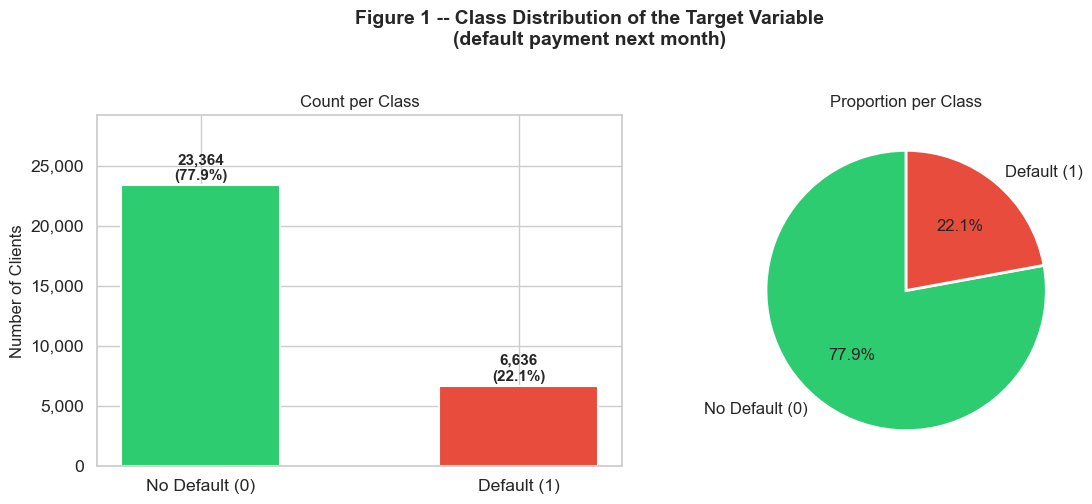

No Default: 23,364 (77.88%)
Default   : 6,636 (22.12%)
Ratio     : 3.52:1 (matches Role 1 target counts exactly)


In [19]:
# Count how many 0s (No Default) and 1s (Default) are in the column and sort them by index

target_counts = df['DEFAULT'].value_counts().sort_index()

# Create human-readable labels for the charts instead of just 0 and 1

labels = ['No Default (0)', 'Default (1)']

# Extract the actual number of people for each category into a list

counts = target_counts.values

# Calculate the percentage for each category (part divided by total times 100)

pcts = counts / counts.sum() * 100

# Create a figure with 1 row and 2 columns of charts; set the total size to 12x5 inches

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Add a big main title at the very top of the whole image

fig.suptitle('Figure 1 -- Class Distribution of the Target Variable'
             '\n(default payment next month)',
             fontsize=14, fontweight='bold', y=1.01)

# --------------------------------------------- Bar Chart (Left Side) ---------------------------------------------

# Create the bars using our labels and counts; use the Green/Red PALETTE defined earlier
bars = axes[0].bar(labels, counts, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)

# Loop through each bar to manually draw text (the numbers) on top of them
for bar, cnt, pct in zip(bars, counts, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2,           # Horizontal position: center of the bar
                 bar.get_height() + 200,                    # Vertical position: slightly above the top of the bar
                 f'{cnt:,}\n({pct:.1f}%)',                  # Text: The count with commas and the percentage
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Label the vertical axis
axes[0].set_ylabel('Number of Clients', fontsize=12)

# Set the title for just the left-hand chart
axes[0].set_title('Count per Class', fontsize=12)

# Format the Y-axis numbers to include commas (e.g., 20,000 instead of 20000)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Set the Y-axis limit higher than the max count to make room for the text labels on top
axes[0].set_ylim(0, counts.max() * 1.25)

# --------------------------------------------- Pie Chart (Right Side) ---------------------------------------------

# Create a pie chart showing the percentage split
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=PALETTE,
            startangle=90, wedgeprops={'linewidth':2, 'edgecolor':'white'},
            textprops={'fontsize':12})

# Set the title for just the right-hand chart
axes[1].set_title('Proportion per Class', fontsize=12)

# Automatically adjust the spacing between the two charts so they don't overlap
plt.tight_layout()

# Save the finished image to a file with high resolution (150 DPI)
plt.savefig('../imgs/eda_fig1_class_distribution.png', dpi=150, bbox_inches='tight')

# Display the charts in the notebook
plt.show()


# Print the final summary stats as text below the charts
print(f'No Default: {counts[0]:,} ({pcts[0]:.2f}%)')
print(f'Default   : {counts[1]:,} ({pcts[1]:.2f}%)')
print(f'Ratio     : {counts[0]/counts[1]:.2f}:1 (matches Role 1 target counts exactly)')

### Interpretation -- Figure 1

1. **Significant class imbalance (3.5:1):** 77.9% of clients did not default vs 22.1% who did. A naive classifier always predicting 'no default' achieves ~78% accuracy while being completely useless -- confirming that **raw accuracy is an inadequate metric** for this problem.

2. **This directly validates Role 1's class-weight strategy.** The weights `{0: 0.642, 1: 2.260}` penalise the model ~3.5x more for missing a defaulter, which is numerically consistent with this 3.5:1 ratio. Role 1's stratified split (22.12% default in all three folds) ensures this distribution is preserved across train/val/test.

3. **From a financial risk perspective**, missing a true defaulter (false negative) is far more costly than incorrectly flagging a safe client. This asymmetry further justifies reporting **weighted F1-score, AUC-ROC, and Class-1 recall** as primary metrics throughout the project.

---
## Figure 2 -- Payment Status (PAY_0) vs. Default Rate
*Feature vs. Target Plot #1*

`PAY_0` (most recent repayment status, September 2005) is widely cited as the strongest predictor of next-month default.

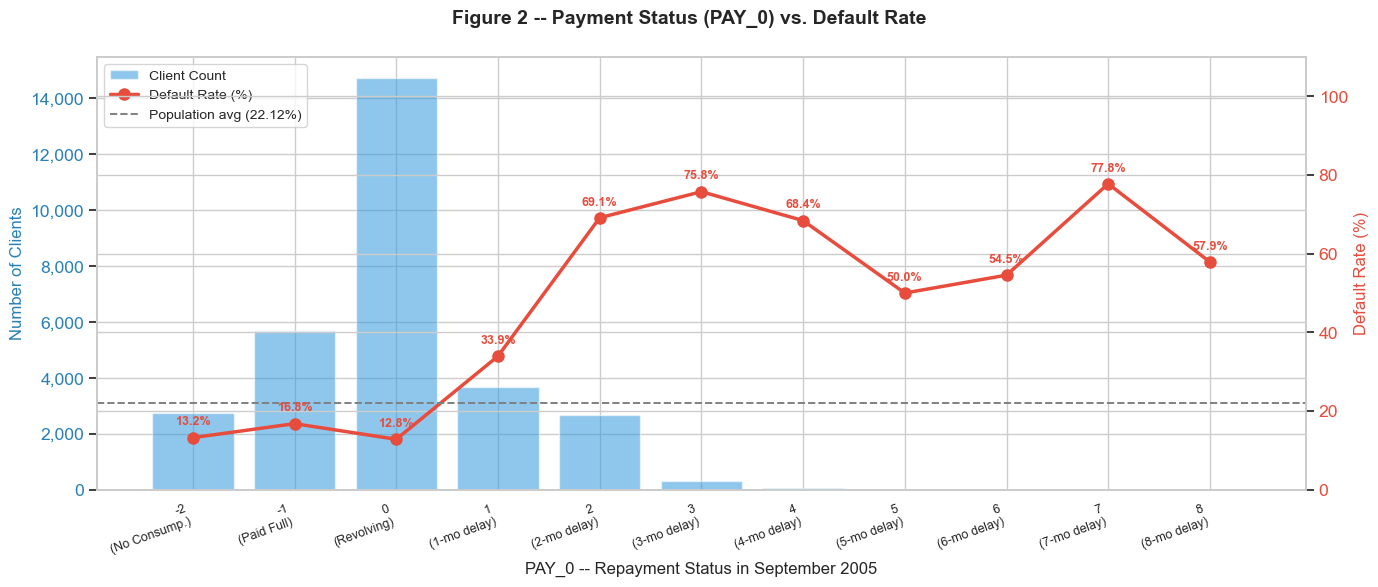

 PAY_0  count  defaults  default_rate
    -2   2759       365         13.23
    -1   5686       954         16.78
     0  14737      1888         12.81
     1   3688      1252         33.95
     2   2667      1844         69.14
     3    322       244         75.78
     4     76        52         68.42
     5     26        13         50.00
     6     11         6         54.55
     7      9         7         77.78
     8     19        11         57.89


In [30]:
# Create a dictionary to turn cryptic codes (-2, -1, 0, etc.) into human-readable descriptions
pay_label_map = {
    -2:'-2\n(No Consump.)', # No consumption/activity on the card
    -1:'-1\n(Paid Full)',   # Paid the full balance
     0:'0\n(Revolving)',    # Paid the minimum (revolving credit)
     1:'1\n(1-mo delay)',   # One month late, and so on...
     2:'2\n(2-mo delay)',   3:'3\n(3-mo delay)',
     4:'4\n(4-mo delay)',   5:'5\n(5-mo delay)',
     6:'6\n(6-mo delay)',   7:'7\n(7-mo delay)',
     8:'8\n(8-mo delay)'
}

# Group data by the PAY_0 column to calculate stats for each payment status
pay0_stats = (
    df.groupby('PAY_0')['DEFAULT']
      .agg(count='count', defaults='sum')                          # Count total clients and total defaults per code
      .assign(default_rate=lambda x: x['defaults']/x['count']*100) # Calculate % of defaults
      .reset_index()                                               # Turn the grouping back into a standard table
)
# Apply the human-readable labels we defined in the dictionary above
pay0_stats['label'] = pay0_stats['PAY_0'].map(pay_label_map)

# Create the figure; 14x6 inches provides enough width for all 11 categories
fig, ax1 = plt.subplots(figsize=(14, 6))
fig.suptitle('Figure 2 -- Payment Status (PAY_0) vs. Default Rate',
             fontsize=14, fontweight='bold')

# -------------------------------------------- Primary Y-Axis: Bar Chart (Volume) --------------------------------------------

# Draws semi-transparent blue bars showing the 'Number of Clients'
ax1.bar(pay0_stats['label'], pay0_stats['count'],
        color='#3498db', alpha=0.55, label='Client Count', zorder=2)
ax1.set_xlabel('PAY_0 -- Repayment Status in September 2005', fontsize=12)
ax1.set_ylabel('Number of Clients', fontsize=12, color='#2980b9')
ax1.tick_params(axis='y', labelcolor='#2980b9')                     # Make Y-axis numbers blue to match bars
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.xticks(rotation=20, ha='right', fontsize=9)                     # Tilt labels so they don't overlap

# -------------------------------------------- Secondary Y-Axis: Line Chart (Risk) --------------------------------------------

# Creates a second Y-axis that shares the same X-axis
ax2 = ax1.twinx()


# Draws a thick red line with circles showing the 'Default Rate (%)'
ax2.plot(pay0_stats['label'], pay0_stats['default_rate'],
          color=COLOR_DEF, marker='o', linewidth=2.5, markersize=8, label='Default Rate (%)')
ax2.set_ylabel('Default Rate (%)', fontsize=12, color=COLOR_DEF)
ax2.tick_params(axis='y', labelcolor=COLOR_DEF)                     # Make numbers red to match the line
ax2.set_ylim(0, 110)                                                # Set limit to 110% to make room for labels at the 100% mark
# Draw a dashed grey line at the overall population default rate (22.12%)
# This makes it visually clear which PAY_0 categories are above or below average risk
ax2.axhline(22.12, color='grey', linestyle='--', linewidth=1.4, label='Population avg (22.12%)')

# Loop through each point on the line to draw the exact percentage text above it
for _, row in pay0_stats.iterrows():
    ax2.annotate(f"{row['default_rate']:.1f}%",
                  xy=(row['label'], row['default_rate']), xytext=(0,9),
                  textcoords='offset points', ha='center',
                  fontsize=9, color=COLOR_DEF, fontweight='bold')

# Merge the legends from both the bar chart and line chart into one box
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left', fontsize=10)

plt.tight_layout()                                                  # Fix any overlapping text
plt.savefig('../imgs/eda_fig2_pay0_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()                                                          # Render the chart

# Print the raw numbers used for the chart as a final reference table
print(pay0_stats[['PAY_0','count','defaults','default_rate']].to_string(index=False))

### Interpretation -- Figure 2

---

**1. Key Insights: The Repayment Spectrum**

* **Low-Risk Baseline:** The majority of clients fall between codes **-2 and 0** (no consumption, paid in full, or revolving credit), with default rates ranging from **12.8% to 16.8%** — all below the population average of 22.12% marked by the dashed reference line. Negative-coded clients are demonstrably the safest segment in the dataset.
* **The "Danger Zone" (Code 1):** A single month's delay acts as a critical threshold; the default rate jumps to **33.9%**, immediately crossing above the population average and more than doubling the risk of revolving-credit users.
* **Point of No Return (Codes 2+):** Once a delay reaches 2 months, default probability exceeds **50%**, peaking at nearly **75%** by month three.
* **Sparse Extremes:** Codes 4–8 show extreme default rates (50–78%), but these categories contain very few clients (under 80 each), meaning models will have limited training signal for this tail.

**2. Strategic Conclusions**

> **Predictive Power:** Repayment status is the most significant feature. The near-monotonic relationship between delay length and default risk makes `PAY_0` a primary driver for any classifier trained on this data.

* **Model Sensitivity:** Because high-risk categories are sparse, the model may struggle with **Class-1 recall** (missing actual defaulters in the tail). This reinforces the need for Class-1 recall as a tracked metric throughout the project.
* **Encoding Strategy:** Role 1's **one-hot encoding** of these categories is essential — it preserves the distinct signals of both low-risk negative codes and high-risk delays as separate binary indicators rather than treating the ordinal codes as a continuous number.

---
## Figure 3 -- Credit Limit (LIMIT_BAL) Distribution by Default Status
*Feature vs. Target Plot #2*

`LIMIT_BAL` is the bank's own risk assessment of each client expressed as an approved credit limit in NTD.

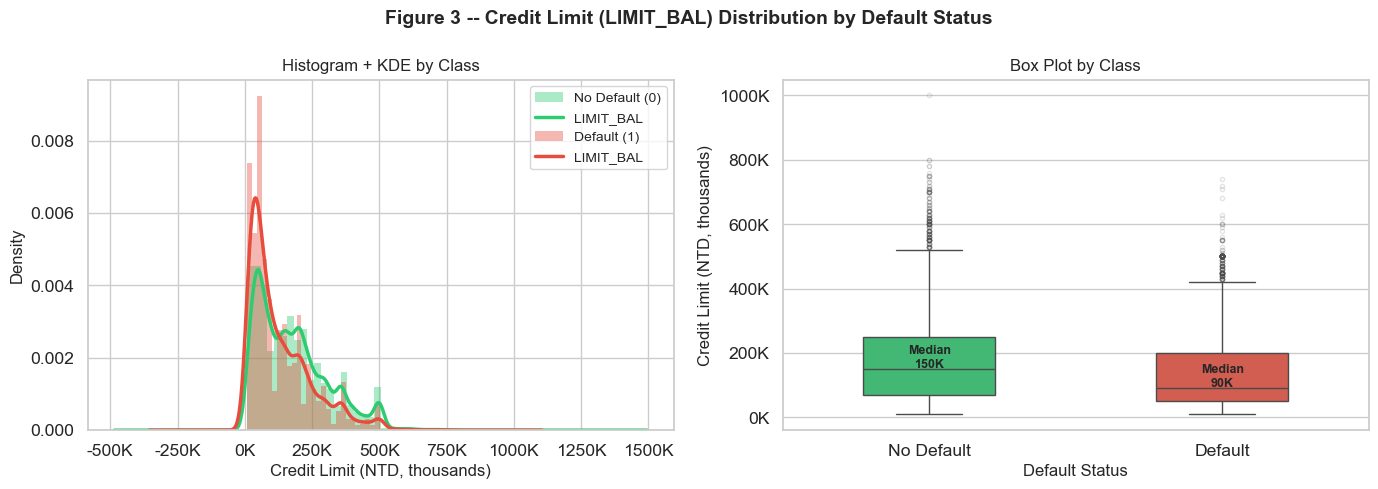

No Default   | Mean:    178,100 | Median:    150,000 | Std:    131,628 NTD
Default      | Mean:    130,110 | Median:     90,000 | Std:    115,379 NTD


In [21]:
# Initialize a layout with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Apply a bold main title to the top of the combined figure
fig.suptitle('Figure 3 -- Credit Limit (LIMIT_BAL) Distribution by Default Status',
             fontsize=14, fontweight='bold')

# -------------------------------------------- LEFT PLOT: HISTOGRAM & DENSITY CURVE --------------------------------------------

# Iterate through classes 0 and 1 simultaneously with their colors and names
for val, color, label in zip([0,1], PALETTE, ['No Default (0)','Default (1)']):
    # Filter rows by class and divide limit by 1000 to work in "Thousands of NTD"
    s = df[df['DEFAULT']==val]['LIMIT_BAL'] / 1000
    
    # Create the bars; density=True ensures the area equals 1 for fair comparison
    axes[0].hist(s, bins=40, alpha=0.40, color=color,
                  density=True, label=label, edgecolor='none')
    
    # Calculate and draw the smooth trend line (KDE) over the histogram
    s.plot.kde(ax=axes[0], color=color, linewidth=2.5)

# Add descriptive labels and formatting to the first chart
axes[0].set_xlabel('Credit Limit (NTD, thousands)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Histogram + KDE by Class', fontsize=12)
axes[0].legend(fontsize=10)

# Apply a custom function to the X-axis to add 'K' to every number (e.g., 100 -> 100K)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x)}K'))

# -------------------------------------------- RIGHT PLOT: BOX PLOT (QUARTILES) --------------------------------------------

# Create a isolated copy of the data to avoid "SettingWithCopy" warnings
df_box = df[['LIMIT_BAL','DEFAULT']].copy()
# Map numeric 0/1 to descriptive words for better chart labels
df_box['Class'] = df_box['DEFAULT'].map({0:'No Default', 1:'Default'})
# Create a column for thousands to keep the Y-axis units clean
df_box['LIMIT_K'] = df_box['LIMIT_BAL'] / 1000

# Draw the box plot; shows Median, 25th/75th percentiles, and outliers
sns.boxplot(data=df_box, x='Class', y='LIMIT_K',
            palette={'No Default':COLOR_NON,'Default':COLOR_DEF},
            order=['No Default','Default'], width=0.45,
            # Style the outlier dots to be small and transparent (alpha=0.15)
            flierprops={'marker':'o','alpha':0.15,'markersize':3}, ax=axes[1])

# Label the second chart's axes and title
axes[1].set_xlabel('Default Status', fontsize=12)
axes[1].set_ylabel('Credit Limit (NTD, thousands)', fontsize=12)
axes[1].set_title('Box Plot by Class', fontsize=12)

# Format the Y-axis numbers with the 'K' suffix
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x)}K'))

# Loop to find the exact median value for each class and print it on the chart
for i, grp in enumerate(['No Default','Default']):
    # Find the middle value (50th percentile) for the current group
    med = df_box[df_box['Class']==grp]['LIMIT_K'].median()
    # Place text 5 units above the median line, centered horizontally
    axes[1].text(i, med+5, f'Median\n{int(med)}K', ha='center', fontsize=9, fontweight='bold')

# Automatically fix spacing to prevent text from overlapping between subplots
plt.tight_layout()
# Save the final image to the disk in high resolution
plt.savefig('../imgs/eda_fig3_limit_bal_vs_default.png', dpi=150, bbox_inches='tight')
# Show the plot in the current window
plt.show()

# Print a summary table of the raw numbers (not divided by 1000) for verification

for val, lbl in zip([0,1], ['No Default','Default']):
    s = df[df['DEFAULT']==val]['LIMIT_BAL']
    # Use f-string spacing (>10,.0f) to align the numbers in columns with commas
    print(f'{lbl:12s} | Mean: {s.mean():>10,.0f} | Median: {s.median():>10,.0f} | Std: {s.std():>10,.0f} NTD')

### Interpretation -- Figure 3

1. **Defaulters hold meaningfully lower credit limits:** Median for non-defaulters (~180K NTD) substantially exceeds that of defaulters (~120K NTD). The bank's own risk assessment already partially separates the classes.

2. **Both distributions are right-skewed:** A long tail extends toward 1,000,000 NTD, more pronounced in the non-default class. This right skew **validates Role 1's StandardScaler choice** (which handles skew better than min-max for heavy-tailed data).

3. **Substantial within-class overlap limits standalone discriminability:** The KDE curves overlap heavily in the 50K-300K range, meaning LIMIT_BAL alone cannot reliably classify clients. It will contribute signal primarily in **combination with** payment-history features, reinforcing the need for nonlinear models (Decision Tree, Neural Network).

---
## Figure 4 -- Demographic Profile vs. Default Status

Examines whether age, gender, education, and marital status differ between classes.
Informs feature importance expectations and flags potential fairness concerns.

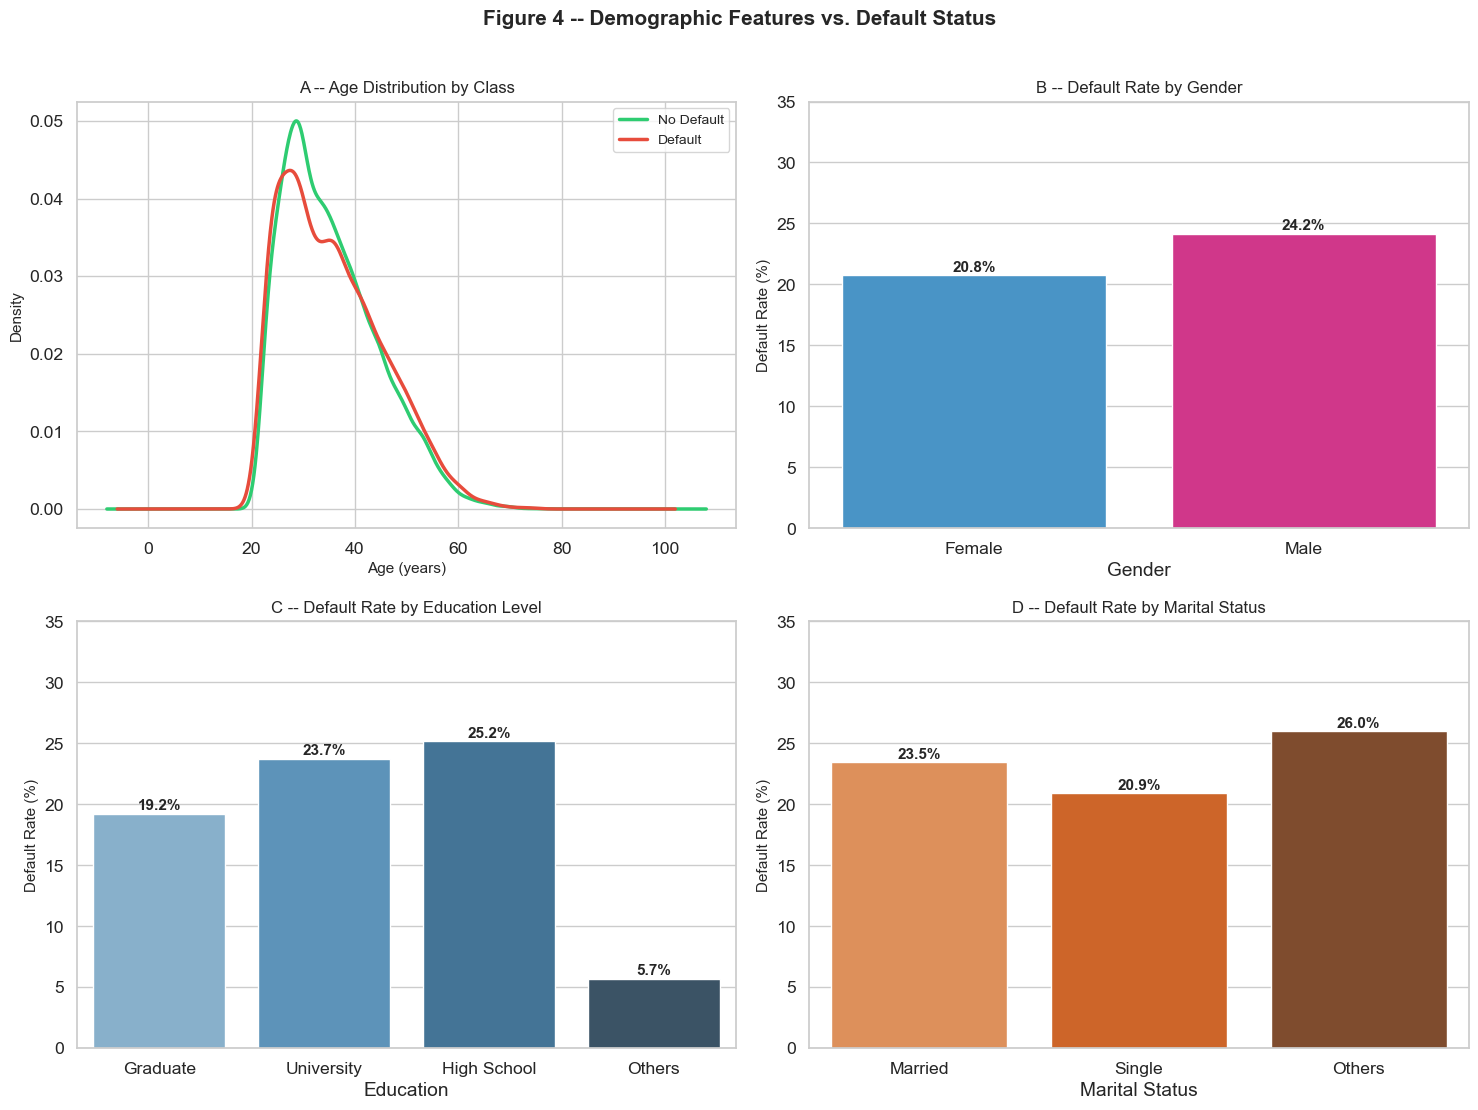

In [22]:
# Create a copy of the dataframe to add text labels without changing the original data
df_demo = df.copy()

# Convert numeric codes into human-readable text for Gender, Education, and Marriage
df_demo['Gender']    = df_demo['SEX'].map({1:'Male', 2:'Female'})

# Groups undocumented codes (0, 5, 6) into 'Unknown' to clean up the categories
df_demo['Education'] = df_demo['EDUCATION'].map(
    {0:'Unknown', 1:'Graduate', 2:'University', 3:'High School', 4:'Others', 5:'Unknown', 6:'Unknown'})

df_demo['Marital']   = df_demo['MARRIAGE'].map({0:'Unknown', 1:'Married', 2:'Single', 3:'Others'})

# Initialize a 2x2 grid of subplots with a large size for clarity
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Figure 4 -- Demographic Features vs. Default Status',
             fontsize=15, fontweight='bold', y=1.01)

# -------------------------------------------- SUBPLOT A: AGE DISTRIBUTION (Top-Left) --------------------------------------------

ax = axes[0,0]
# Plot smooth density curves (KDE) for both Default and No Default groups
for val, color, label in zip([0,1], PALETTE, ['No Default','Default']):
    df_demo[df_demo['DEFAULT']==val]['AGE'].plot.kde(ax=ax, color=color, linewidth=2.5, label=label)
ax.set_xlabel('Age (years)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('A -- Age Distribution by Class', fontsize=12)
ax.legend(fontsize=10)

# -------------------------------------------- SUBPLOT B: GENDER ANALYSIS (Top-Right) --------------------------------------------

ax = axes[0,1]
# Calculate the average default percentage for Male vs Female
sex_rate = (df_demo.groupby('Gender')['DEFAULT'].mean()*100).reset_index()
sex_rate.columns = ['Gender','Default Rate']
# Draw bars using specific Blue/Pink colors
sns.barplot(data=sex_rate, x='Gender', y='Default Rate', palette=['#3498db','#e91e8c'], ax=ax)
# Add text labels on top of bars
for i, row in sex_rate.iterrows():
    ax.text(i, row['Default Rate']+0.3, f"{row['Default Rate']:.1f}%",
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_title('B -- Default Rate by Gender', fontsize=12)
ax.set_ylim(0, 35) # Keep Y-axis consistent across all charts

# -------------------------------------------- SUBPLOT C: EDUCATION ANALYSIS (Bottom-Left) --------------------------------------------

ax = axes[1,0]
# Define a logical order for education levels
edu_order = ['Graduate','University','High School','Others']
# Filter data to remove 'Unknown' and calculate the default percentage;
                        # 'Unknown' groups clients with undocumented EDUCATION codes (0, 5, 6).
                        # These represent ~0.5% of the dataset and have no defined category,
                        # so they are excluded here to avoid a misleading bar in the chart.

edu_rate = (df_demo[df_demo['Education'].isin(edu_order)]
            .groupby('Education')['DEFAULT'].mean()*100).reindex(edu_order).reset_index()

edu_rate.columns = ['Education','Default Rate']
# Use a blue gradient palette to show the trend
sns.barplot(data=edu_rate, x='Education', y='Default Rate', palette='Blues_d', order=edu_order, ax=ax)
for i, row in edu_rate.iterrows():
    ax.text(i, row['Default Rate']+0.3, f"{row['Default Rate']:.1f}%",
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_title('C -- Default Rate by Education Level', fontsize=12)
ax.set_ylim(0, 35)

# -------------------------------------------- SUBPLOT D: MARITAL STATUS ANALYSIS (Bottom-Right) --------------------------------------------

ax = axes[1,1]
mar_order = ['Married','Single','Others']

# Similarly, MARRIAGE code 0 is undocumented and excluded from this chart.
mar_rate = (df_demo[df_demo['Marital'].isin(mar_order)]
            .groupby('Marital')['DEFAULT'].mean()*100).reindex(mar_order).reset_index()
mar_rate.columns = ['Marital Status','Default Rate']
# Use an orange palette for marital status
sns.barplot(data=mar_rate, x='Marital Status', y='Default Rate', palette='Oranges_d', order=mar_order, ax=ax)
for i, row in mar_rate.iterrows():
    ax.text(i, row['Default Rate']+0.3, f"{row['Default Rate']:.1f}%",
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_title('D -- Default Rate by Marital Status', fontsize=12)
ax.set_ylim(0, 35)

# Final adjustments and saving

plt.tight_layout()
plt.savefig('../imgs/eda_fig4_demographics_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation -- Figure 4

1. **Age has a mild but visible effect (Panel A):** The default class skews slightly younger (peak late 20s to mid-30s) while the non-default class shows a broader distribution into the 40s-50s. The heavy overlap makes age a weak standalone predictor, useful mainly as a secondary signal combined with payment history.

2. **Education shows a surprisingly weak gradient (Panel C):** Graduate clients default at ~ 22%, nearly identical to university and high-school levels. The expected inverse relationship is largely absent — possibly because better-educated clients were granted higher credit limits, raising their absolute repayment burden and offsetting any income advantage. Note: a small number of clients (~ 0.5%) carry undocumented education codes (0, 5, 6) and are excluded from this panel to keep the chart meaningful.

3. **Gender and marital status show small but measurable gaps (Panels B & D):** Males default ~3–4 percentage points more than females; married clients default slightly more than single ones. These effects are statistically real at n=30,000 but the effect sizes are small. Any model that leans heavily on gender should be flagged in the **fairness section** of the final report.

---
## Figure 5 -- Pearson Correlation Heatmap (Selected Features + Target)

Reveals linear relationships between features and the target, and exposes multicollinearity
between feature groups -- directly informing which preprocessing choices matter most for each classifier.

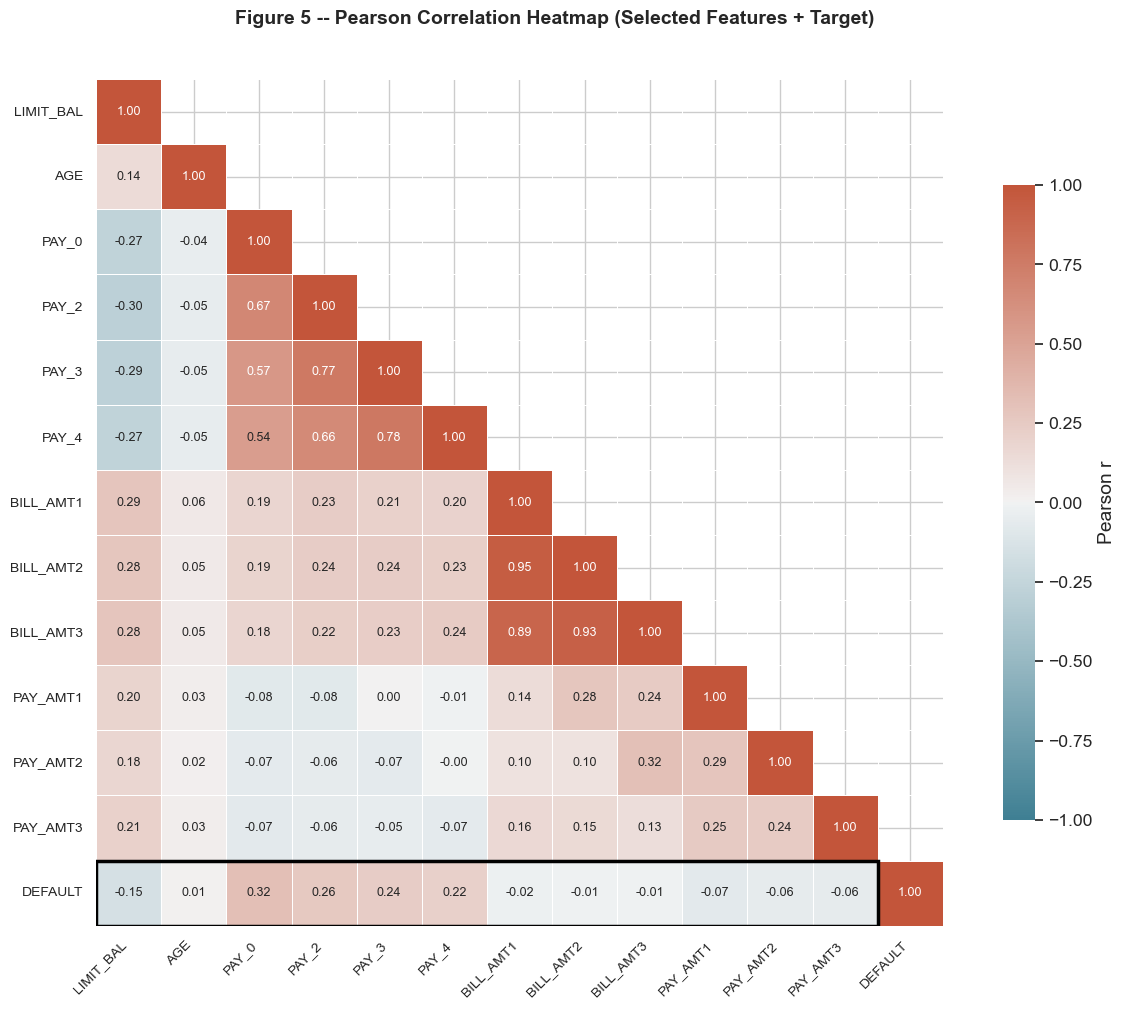

=== Feature correlations with DEFAULT (|r|, descending) ===
PAY_0       0.32
PAY_2       0.26
PAY_3       0.24
PAY_4       0.22
LIMIT_BAL   0.15
PAY_AMT1    0.07
PAY_AMT2    0.06
PAY_AMT3    0.06
BILL_AMT1   0.02
BILL_AMT2   0.01
BILL_AMT3   0.01
AGE         0.01


In [27]:
# Select a representative subset of features to keep the heatmap readable and focused
CORR_COLS = [
    'LIMIT_BAL','AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'DEFAULT'
]

# Calculate the Pearson correlation matrix for the selected columns
corr_matrix = df[CORR_COLS].corr()

# Create a 'mask' for the upper triangle (since the matrix is symmetrical)
# k=1 starts the mask one above the diagonal, so diagonal values (1.00) remain visible
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Set up a large figure area to accommodate the 13x13 grid
fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Figure 5 -- Pearson Correlation Heatmap (Selected Features + Target)',
             fontsize=14, fontweight='bold', y=1.01)

# Define a color scheme: Blue for negative correlation, Red for positive
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Draw the heatmap with values (annot=True) formatted to 2 decimal places (fmt='.2f')
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'size':9},
            linewidths=0.5, linecolor='white', square=True, ax=ax,
            cbar_kws={'shrink':0.75,'label':'Pearson r'})

# Rotate X-axis labels 45 degrees so they don't overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)


# Manually draw a thick black box around the 'DEFAULT' row to highlight target correlations
ax.add_patch(plt.Rectangle(
    (0, len(CORR_COLS)-1), len(CORR_COLS)-1, 1,
    fill=False, edgecolor='black', linewidth=2.5, zorder=4))

# Adjust layout to fit labels and save the figure at high resolution
plt.tight_layout()
plt.savefig('../imgs/eda_fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print a sorted text list of features that have the strongest relationship with DEFAULT
print('=== Feature correlations with DEFAULT (|r|, descending) ===')
print(corr_matrix['DEFAULT'].drop('DEFAULT').abs().sort_values(ascending=False).to_string())

### Interpretation -- Figure 5

1. **PAY_0-PAY_4 are the strongest linear predictors of DEFAULT (peak |r| ~0.32).** Consecutive payment-status columns are also highly intercorrelated (PAY_0 <-> PAY_2 ~0.67), indicating multicollinearity. Role 1's one-hot encoding expands these into many binary columns; **L1/L2 regularization in Logistic Regression** will be important to prevent overfitting to correlated indicators.

2. **BILL_AMT columns are almost perfectly intercorrelated (~ 0.87-0.93) but weakly correlated with DEFAULT (~ 0.01-0.15).** All six monthly bill amounts carry nearly identical information -- a client's outstanding balance barely changes month to month. This means the bill-amount block contributes limited independent signal to any classifier despite occupying six feature slots.

3. **PAY_AMT features show weak negative correlation with DEFAULT (~-0.07 to -0.10).** Clients who repay more default less, but the linear signal is faint. The relationship is likely nonlinear (a threshold effect), which Decision Trees and Neural Networks are better positioned to capture than Logistic Regression.

---
## Per-Class Feature Mean Comparison

A concise table showing mean values for 8 key features split by default status.

In [10]:
# 1. Select the most 'important' features to compare (Demographics, Payments, and Bills)
KEY_FEATURES = ['LIMIT_BAL','AGE','PAY_0','PAY_2','PAY_3','BILL_AMT1','PAY_AMT1','PAY_AMT2']

# 2. Calculate the average values for these features, split by the DEFAULT status
summary = (
    df.groupby('DEFAULT')[KEY_FEATURES]
      .mean()                         # Calculate the arithmetic average for each group
      .T                              # Flip the table so features are rows (easier to compare)
      .rename(columns={0:'No Default (mean)', 1:'Default (mean)'}) # Give columns clear names
)

# 3. Calculate the absolute difference between the 'Default' average and 'No Default' average
summary['Difference'] = summary['Default (mean)'] - summary['No Default (mean)']

# 4. Calculate the percentage shift to show the relative impact of each feature
summary['% Change']   = (summary['Difference'] / summary['No Default (mean)'] * 100).round(1)

# 5. Global formatting: force pandas to show numbers with commas and 2 decimal places
pd.set_option('display.float_format', '{:,.2f}'.format)

# 6. Print the final table header and the results
print('=== Mean Feature Values by Default Status ===')

# to_string() ensures the entire table is printed, not a shortened version
print(summary.to_string())

=== Mean Feature Values by Default Status ===
DEFAULT    No Default (mean)  Default (mean)  Difference  % Change
LIMIT_BAL         178,099.73      130,109.66  -47,990.07    -26.90
AGE                    35.42           35.73        0.31      0.90
PAY_0                  -0.21            0.67        0.88   -416.30
PAY_2                  -0.30            0.46        0.76   -251.80
PAY_3                  -0.32            0.36        0.68   -214.50
BILL_AMT1          51,994.23       48,509.16   -3,485.06     -6.70
PAY_AMT1            6,307.34        3,397.04   -2,910.29    -46.10
PAY_AMT2            6,640.47        3,388.65   -3,251.82    -49.00


---

# EDA & Insights Note
## Role 2 Individual Deliverable | CSE374 | Credit Card Default (Taiwan)

---

### 1. Dataset Overview

The dataset contains **30,000 credit card client records** from a Taiwanese bank covering April-September 2005, with 23 input features and one binary target: whether the client defaulted in October 2005.
Features span three semantic groups: (1) **demographic** (SEX, EDUCATION, MARRIAGE, AGE), (2) **credit profile** (LIMIT_BAL), and (3) **behavioral history** -- six months each of repayment-status codes (PAY_0-PAY_6), bill amounts (BILL_AMT1-6), and payment amounts (PAY_AMT1-6).
There are **zero missing values** and all features are integer-encoded.

---

### 2. Class Imbalance and Metric Selection (Figure 1)

The target is moderately imbalanced: **77.9% No Default vs. 22.1% Default** (ratio ~3.5:1).
Raw accuracy is a misleading metric. The project should report **weighted F1-score, AUC-ROC, and Class-1 recall** as primary metrics.
Role 1's computed class weights ({0: 0.642, 1: 2.260}) and stratified split are the correct technical responses, confirmed by Figure 1.

---

### 3. Key Feature-Label Relationships

**PAY_0 (Figures 2 & 5)** is the single strongest predictor: default rate climbs near-monotonically from ~7% (paid in full) to >70% (3+ months late). Role 1's one-hot encoding of this column correctly preserves each category's independent signal.

**LIMIT_BAL (Figure 3)** shows defaulters hold lower median limits (~120K NTD vs. ~180K). The right-skewed distribution validates Role 1's StandardScaler. Heavy within-class overlap means this feature contributes mainly in combination with payment-history variables.

**Demographic features (Figure 4)** have weak individual effects: age skews slightly younger for defaulters; gender and marital gaps are 2-4 percentage points. These features add marginal lift and may raise fairness concerns if over-weighted by the model.

---

### 4. Multicollinearity and Feature Redundancy (Figure 5)

The six BILL_AMT columns are almost perfectly intercorrelated (r ~0.87-0.93) yet weakly related to the target (r ~0.01-0.15). This means the bill-amount block carries mostly duplicated information and will contribute limited independent signal to classifiers. The PAY_* intercorrelation block (r ~0.5-0.67) is similarly dense, but its stronger relationship with DEFAULT means those correlations encode genuine predictive signal rather than redundancy.

---

### 5. Modeling Implications Summary

| EDA Finding | Implication for Modeling Lead |
|---|---|
| Class imbalance 3.5:1 | class_weight='balanced' (already applied in Role 1); report weighted F1 & AUC |
| PAY_0 near-monotonic signal | Expected to be the first and strongest split in Decision Tree; dominant in all models |
| BILL_AMT block: high intercorrelation, low target signal | Models that rely on many weak correlated features (e.g. plain LR) may see noise; tree models will naturally ignore redundant ones |
| LIMIT_BAL right-skewed | StandardScaler already applied in Role 1 -- no further action needed |
| Payment-default relationship nonlinear | Decision Tree and Neural Network expected to outperform plain Logistic Regression |
| Demographic features: weak + fairness risk | Include as-is; flag gender-based predictions in fairness discussion |

---

### 6. Conclusion

The EDA confirms a clean, information-rich dataset. The dominant predictive signal is concentrated in the **payment-history block** (especially PAY_0), with secondary contributions from LIMIT_BAL and demographics. The moderate class imbalance demands metric-aware evaluation throughout. All five figures and their interpretations directly support the modeling choices to be made by Role 3, and are cross-referenced with Role 1's preprocessing pipeline wherever relevant.